### Polynomial Regression Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.rand(100, 1)

## Quadratic Equation used = y = 0.5x^2+1.5x+outliers

Text(0, 0.5, 'Y Dataset')

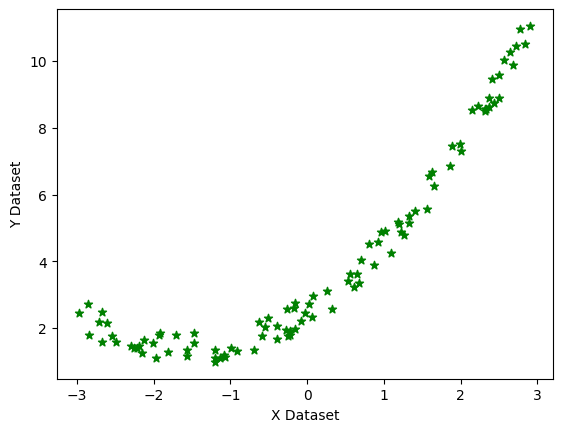

In [3]:
plt.scatter(X,y, c='g', marker="*")
plt.xlabel('X Dataset')
plt.ylabel("Y Dataset")

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
regression_1 = LinearRegression()
regression_1.fit(X_train, y_train)


LinearRegression()

In [6]:
linear_score = r2_score(y_test, regression_1.predict(X_test))
linear_score

0.7887808396222011

Plotting the Best fit line with respect to the Data distribution where the error is too much

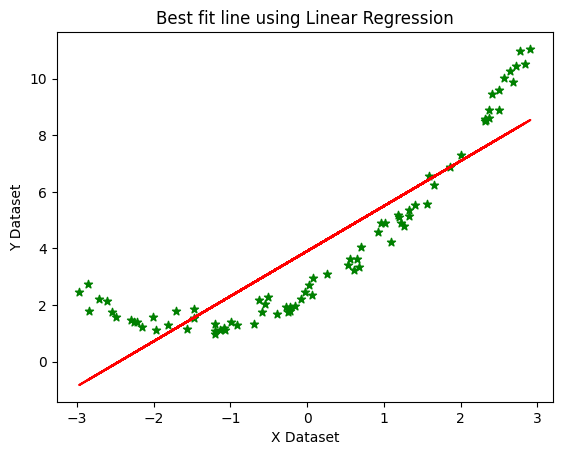

In [7]:
plt.title("Best fit line using Linear Regression")
plt.plot(X_train, regression_1.predict(X_train), c = 'r')
plt.scatter(X_train, y_train, c='g', marker='*')
plt.xlabel("X Dataset")
plt.ylabel("Y Dataset")
plt.show()
plt.close()

### Solving this problem using the Polynomial Transformation


In [8]:
from sklearn.preprocessing import PolynomialFeatures

In [9]:
poly = PolynomialFeatures(degree=2, include_bias=True) # It is add the 1 in equation like (y = b0*1 + b1x1 +b2x1^2 ) so here 1 is your include_bias = True

In [10]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

In [11]:
X_train_poly # Here the 1st value is 1, 2nd value is x1 and 3rd value is x^2

array([[ 1.00000000e+00, -2.25568511e+00,  5.08811530e+00],
       [ 1.00000000e+00,  1.19335789e+00,  1.42410306e+00],
       [ 1.00000000e+00,  2.56673485e+00,  6.58812781e+00],
       [ 1.00000000e+00,  1.86169314e+00,  3.46590136e+00],
       [ 1.00000000e+00, -2.75708189e-01,  7.60150053e-02],
       [ 1.00000000e+00, -1.97169153e+00,  3.88756747e+00],
       [ 1.00000000e+00, -1.20534222e+00,  1.45284987e+00],
       [ 1.00000000e+00,  1.55655796e+00,  2.42287268e+00],
       [ 1.00000000e+00, -1.20016389e+00,  1.44039337e+00],
       [ 1.00000000e+00,  1.22346131e+00,  1.49685759e+00],
       [ 1.00000000e+00, -2.18200504e-01,  4.76114601e-02],
       [ 1.00000000e+00,  1.32580138e+00,  1.75774929e+00],
       [ 1.00000000e+00, -2.21830575e+00,  4.92088041e+00],
       [ 1.00000000e+00,  1.01200918e+00,  1.02416258e+00],
       [ 1.00000000e+00,  1.41140568e+00,  1.99206601e+00],
       [ 1.00000000e+00,  6.51479684e-01,  4.24425779e-01],
       [ 1.00000000e+00,  1.08751008e+00

In [12]:
X_test_poly

array([[ 1.        , -1.56952266,  2.46340137],
       [ 1.        ,  2.22199062,  4.9372423 ],
       [ 1.        , -1.92685479,  3.71276937],
       [ 1.        , -1.92182154,  3.69339802],
       [ 1.        , -0.39535683,  0.15630702],
       [ 1.        ,  2.14621368,  4.60623316],
       [ 1.        , -2.12555263,  4.51797397],
       [ 1.        ,  1.62651926,  2.64556491],
       [ 1.        , -2.67330705,  7.14657058],
       [ 1.        ,  0.33024547,  0.10906207],
       [ 1.        ,  0.8673569 ,  0.752308  ],
       [ 1.        ,  2.43829124,  5.94526415],
       [ 1.        ,  1.98604914,  3.94439119],
       [ 1.        , -2.67001488,  7.12897946],
       [ 1.        , -0.25590037,  0.065485  ],
       [ 1.        ,  0.80358221,  0.64574437],
       [ 1.        , -0.15205104,  0.02311952],
       [ 1.        ,  1.89019652,  3.57284288],
       [ 1.        , -2.19466758,  4.8165658 ],
       [ 1.        , -0.16823549,  0.02830318]])

#### Let's Analyze the  r2 score

In [13]:
regression_2 = LinearRegression()
regression_2.fit(X_train_poly, y_train)
y_pred = regression_2.predict(X_test_poly)
polynomial_score = r2_score(y_test, y_pred)
polynomial_score

0.9792573702598509

In [14]:
print(f"r2_score with Linear Regression: {linear_score} \nr2_score with Polynomial Regression: {polynomial_score}")

r2_score with Linear Regression: 0.7887808396222011 
r2_score with Polynomial Regression: 0.9792573702598509


In [15]:
regression_1.coef_

array([[1.59463062]])

In [16]:
regression_2.coef_

array([[0.        , 1.52231799, 0.50783152]])

### Visualize the Polynomial Regression Best fit line

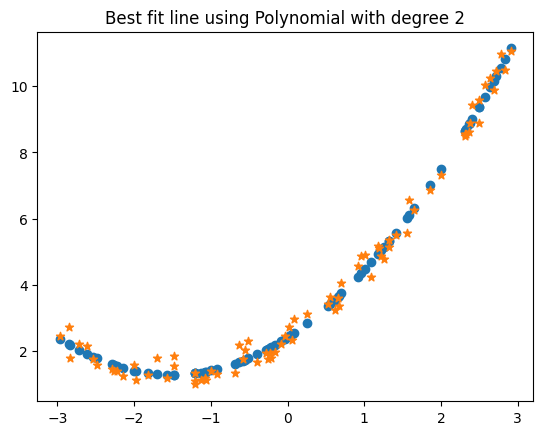

In [17]:
plt.title("Best fit line using Polynomial with degree 2")
plt.scatter(X_train, regression_2.predict(X_train_poly))
plt.scatter(X_train, y_train , marker='*')

### Let's apply the deg=3 

In [18]:
poly = PolynomialFeatures(degree=3, include_bias=True) # It is add the 1 in equation like (y = b0*1 + b1x1 +b2x1^2 + b3x1^3) so here 1 is your include_bias = True
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

In [19]:
X_train_poly ## here you see the 4 points which is b0, b1, b2 and b3

array([[ 1.00000000e+00, -2.25568511e+00,  5.08811530e+00,
        -1.14771859e+01],
       [ 1.00000000e+00,  1.19335789e+00,  1.42410306e+00,
         1.69946462e+00],
       [ 1.00000000e+00,  2.56673485e+00,  6.58812781e+00,
         1.69099773e+01],
       [ 1.00000000e+00,  1.86169314e+00,  3.46590136e+00,
         6.45244479e+00],
       [ 1.00000000e+00, -2.75708189e-01,  7.60150053e-02,
        -2.09579594e-02],
       [ 1.00000000e+00, -1.97169153e+00,  3.88756747e+00,
        -7.66508384e+00],
       [ 1.00000000e+00, -1.20534222e+00,  1.45284987e+00,
        -1.75118129e+00],
       [ 1.00000000e+00,  1.55655796e+00,  2.42287268e+00,
         3.77134174e+00],
       [ 1.00000000e+00, -1.20016389e+00,  1.44039337e+00,
        -1.72870812e+00],
       [ 1.00000000e+00,  1.22346131e+00,  1.49685759e+00,
         1.83134735e+00],
       [ 1.00000000e+00, -2.18200504e-01,  4.76114601e-02,
        -1.03888446e-02],
       [ 1.00000000e+00,  1.32580138e+00,  1.75774929e+00,
      

In [20]:
regression_3 = LinearRegression()
regression_3.fit(X_train_poly, y_train)
y_pred = regression_3.predict(X_test_poly)
polynomial_score_3 = r2_score(y_test, y_pred)
polynomial_score_3

0.9792861264275933

In [21]:
print(f"r2_score with Polynomial Regression deg 1: {linear_score} \nr2_score with Polynomial Regression deg 2: {polynomial_score} \nr2_score with Polynomial Regression deg 3: {polynomial_score_3}")

r2_score with Polynomial Regression deg 1: 0.7887808396222011 
r2_score with Polynomial Regression deg 2: 0.9792573702598509 
r2_score with Polynomial Regression deg 3: 0.9792861264275933


Here you can see that clearly on the non linear dataset the linear regression is not give the good accuracy and the polynomial regression with degree 2 and degree 3 give the good accuracy

### Prediction on new data set

In [22]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new) # deg=3


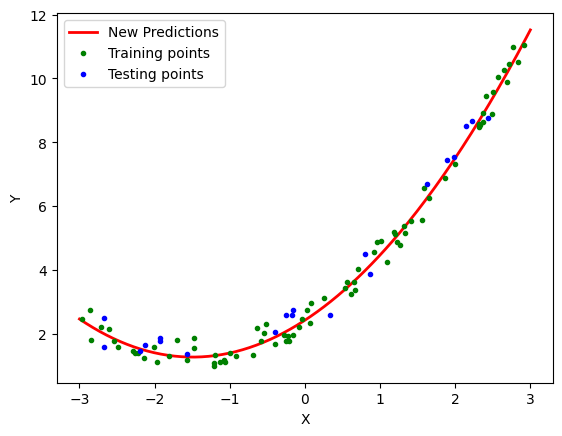

In [23]:
y_new = regression_3.predict(X_new_poly)
plt.plot(X_new, y_new, 'r-', linewidth=2, label = "New Predictions")
plt.plot(X_train, y_train, 'g.', linewidth=2, label = "Training points")
plt.plot(X_test, y_test, 'b.', linewidth=2, label = "Testing points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

## Or 

# y_new = regression_3.predict(X_new_poly)
# plt.plot(X_new, y_new, 'r-', linewidth=2, label="Predictions")
# plt.scatter(X_train, y_train, color='g', marker='.', linewidths=2, label="Training points")
# plt.scatter(X_test, y_test, color='b', marker='.', linewidths=2, label="Testing points")
# plt.xlabel("X")
# plt.ylabel("Y")
# plt.legend()
# plt.show()

## Both the code gives you same plot

### Pipeline Concept

In [24]:
from sklearn.pipeline import Pipeline

In [25]:
def poly_regression(degree):
        X_new = np.linspace(-3, 3, 200).reshape(200, 1)
        poly_features = PolynomialFeatures(degree=degree, include_bias=True)
        lin_reg = LinearRegression()
        poly_regression = Pipeline([
                ("poly_features", poly_features),
                ("lin_reg", lin_reg)
        ])

        poly_regression.fit(X_train, y_train)
        y_pred_new = poly_regression.predict(X_new)

        ## Plotting the prediction line
        plt.plot(X_new, y_pred_new, 'r', label = 'Degree '+ str(degree), linewidth=3)
        plt.plot(X_train, y_train, 'b.', linewidth=3, label = 'Training Datapoints')
        plt.plot(X_test, y_test, 'g.', linewidth=3, label = 'Testing Datapoints')
        plt.legend(loc= 'upper left')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.axis([-4, 4, 0, 10])
        plt.show()

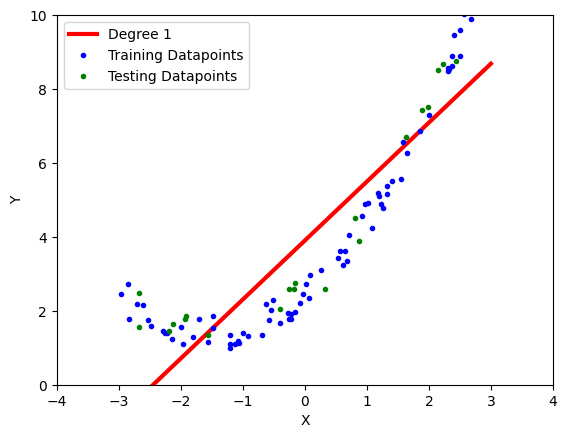

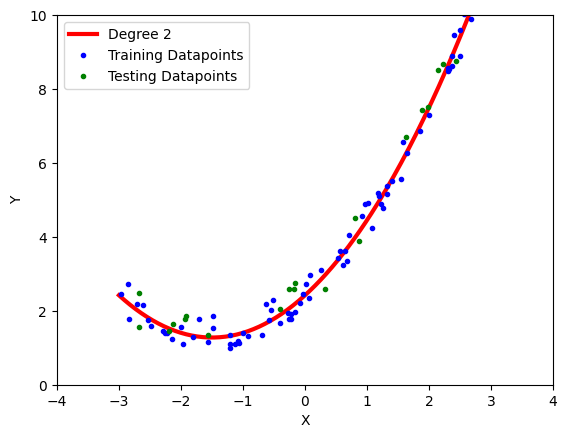

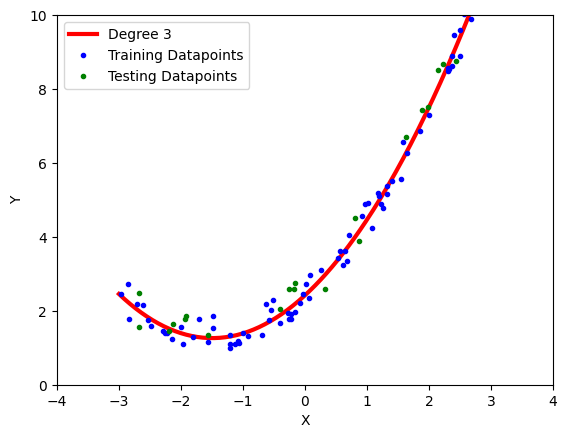

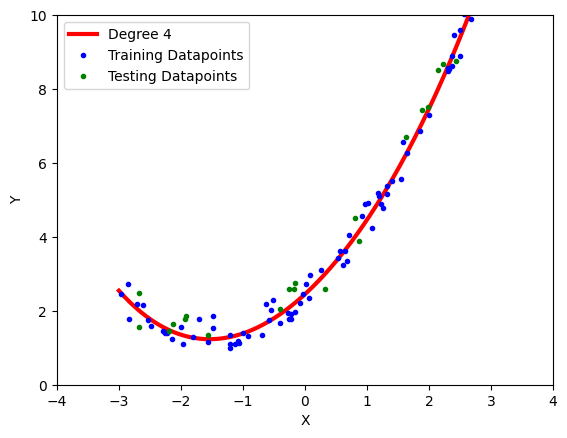

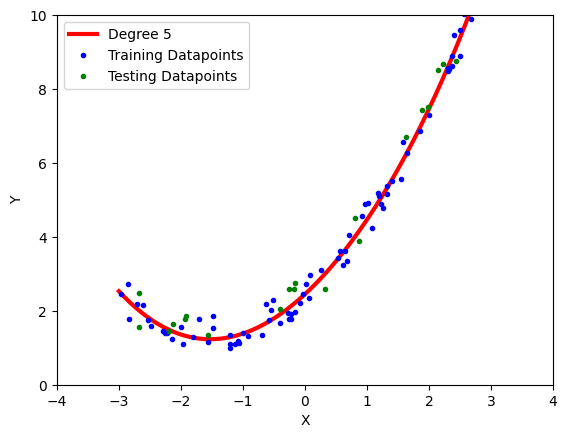

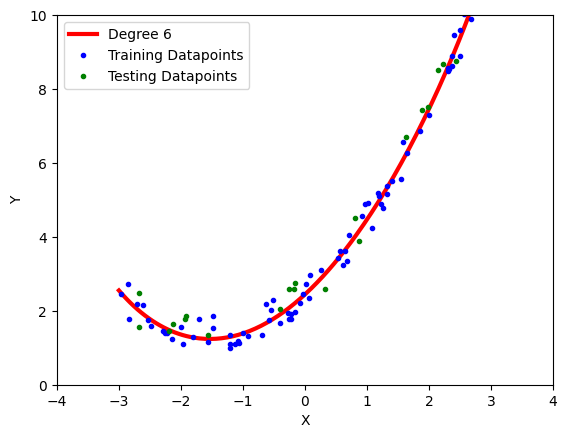

In [26]:
for i in range(1,7):
        poly_regression(i)

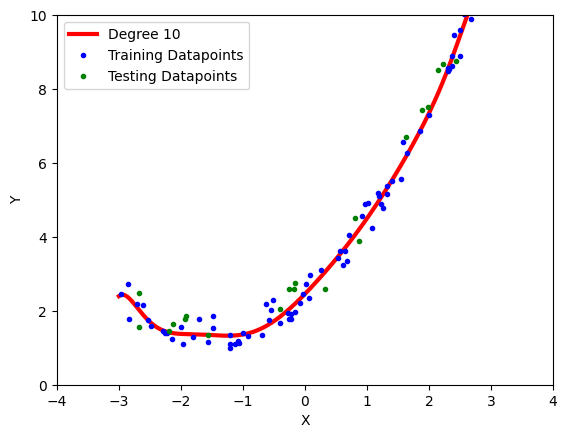

In [27]:
poly_regression(10) ## Overfitting the Model

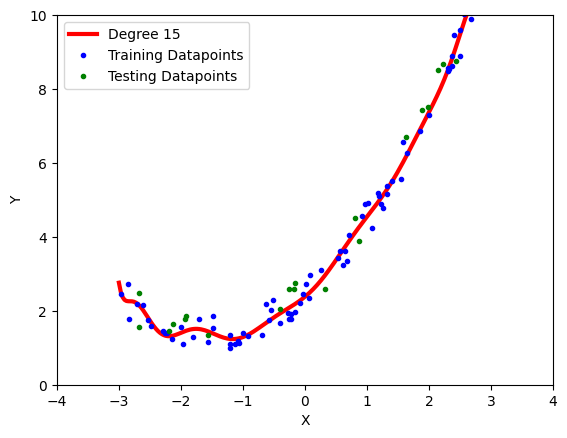

In [28]:
poly_regression(15) ## Overfitting the Model